In [1]:
import os
import time
import numpy as np
import cv2
import sys
import random
import colorsys
from matplotlib.patches import Rectangle
import matplotlib.pyplot as plt
from copy import deepcopy
from IPython.display import display, Image, clear_output

%matplotlib inline

In [2]:
cap = cv2.VideoCapture(0) # カメラからデバイス情報を取得
cap.set(cv2.CAP_PROP_FRAME_WIDTH, 416) # 表示画像の幅を設定
cap.set(cv2.CAP_PROP_FRAME_HEIGHT, 416) # 表示画像の高さを設定
cap.set(cv2.CAP_PROP_FPS, 120) # 表示画像のfpsを設定

True

In [3]:
# 画像を出力する関数
def imshow(frame):
   # 文字を描画（FPS)
    cv2.putText(frame, "FPS : " + str(fps) , (10, 25), cv2.FONT_HERSHEY_COMPLEX, 1, (255, 0, 0), 2, cv2.LINE_AA)
    _, buf = cv2.imencode(".jpg", frame) # エンコード方法にJPEGを指定
    display(Image(data=buf.tobytes()))
    clear_output(wait=True)

In [4]:
#OpenCVのタイマーの準備
timer = cv2.TickMeter()
timer.start()

In [5]:
#各変数の初期値設定(FPS)
count = 0
max_count =30
fps = 0

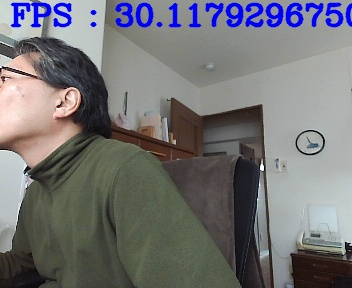

In [ ]:
# メイン処理
while True:
    try:
        ret, frame = cap.read() # デバイス情報から読み込み情報と画像を取得
        
        # 画像が読み込めていない場合は処理を打ち切る
        if not ret:
            break

        #Max_Countの回数になったら、その枚数を取得するのにかかった時間を求めてFPSを算出
        if count == max_count:
            timer.stop()
            fps = max_count / timer.getTimeSec()
            #print("FPS(Actual):" , '{:11.02f}'.format(fps))        
            #リセットと再スタート
            timer.reset()
            count = 0
            timer.start() 

        orig_frame = deepcopy(frame)
        # 推論前処理
        input_img = cv2.resize(frame, (416, 416))  # YOLOv3 のサイズ
        input_img = input_img.astype('float32') / 255.0
        input_img = input_img.transpose(2, 0, 1)
        input_img = input_img.reshape(1, 3, 416, 416)
        
        imshow(orig_frame) # 処理された画像を出力
        count += 1

    # 停止ボタン■で停止
    except KeyboardInterrupt:
        break